In [1]:
!pip install shap

In [2]:
pip install --upgrade numpy pandas --force-reinstall

  Using cached numpy-2.3.4-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.3.4-cp314-cp314-macosx_14_0_arm64.whl (5.1 MB)
Using cached pandas-2.3.3-cp314-cp314-macosx_11_0_arm64.whl (10.8 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata━━━━━━━━━━━━

1. Introduction

Purpose of the notebook

Goal: Build Random Forest model to predict claim cost (claimcst0)

2. Import Libraries

pandas

numpy

matplotlib / seaborn

sklearn (RandomForestRegressor, preprocessing, metrics)

shap

In [3]:
# 2. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
import warnings
warnings.filterwarnings("ignore")


/Users/fogellmcmuffin/anaconda3/envs/datathon/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3. Load Data

Load _data/train.csv

Load _data/test.csv

Show first few rows

In [4]:
# 3. Load Data

train = pd.read_csv("../_data/train.csv")
test  = pd.read_csv("../_data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()
# test.head()

Train shape: (15000, 24)
Test shape: (15000, 19)


,id,fold,sample,veh_value,exposure,veh_body,veh_age,gender,area,agecat,...,marital_status,e_bill,time_of_week_driven,time_driven,trm_len,credit_score,low_education_ind,clm,numclaims,claimcst0
0,1,2,1|bld,5.80,0.362191,SUV,2,F,B,1,...,M,0,weekday,12pm - 6pm,6,646.516469,0.0,1,1,2023.198184
1,2,3,1|bld,5.67,0.632068,STNWG,4,F,A,2,...,S,0,weekend,6am - 12pm,12,635.400369,0.0,1,1,3600.172234
2,3,1,1|bld,5.90,0.367460,SEDAN,2,F,C,2,...,M,0,weekday,6am - 12pm,12,646.463131,0.0,1,1,2021.144067
3,4,2,1|bld,4.79,0.802184,STNWG,3,M,B,4,...,M,1,weekday,6pm - 12am,12,645.598794,0.0,1,1,4006.845492
4,5,2,1|bld,6.68,0.485009,SEDAN,3,M,C,1,...,S,0,weekday,6am - 12pm,12,657.348612,0.0,1,1,2542.953931


4. Train/Validation Split

Use:

train_bld = train[train["sample"] == "1|bld"]

val = train[train["sample"] == "2|val"]

In [5]:
# 4. Train/Validation Split

train_bld = train[train["sample"] == "1|bld"].copy()
val = train[train["sample"] == "2|val"].copy()

print("Training subset:", train_bld.shape)
print("Validation subset:", val.shape)

train_bld.head()
val.head()

Training subset: (11204, 24)
Validation subset: (3796, 24)


,id,fold,sample,veh_value,exposure,veh_body,veh_age,gender,area,agecat,...,marital_status,e_bill,time_of_week_driven,time_driven,trm_len,credit_score,low_education_ind,clm,numclaims,claimcst0
9,10,4,2|val,6.49,0.746884,TRUCK,4,F,B,2,...,M,0,weekday,12pm - 6pm,12,648.136355,0.0,1,1,3906.881054
13,14,4,2|val,6.56,0.848036,SEDAN,3,M,D,4,...,S,1,weekday,6am - 12pm,12,654.686205,0.0,1,1,4260.552605
14,15,4,2|val,6.09,0.356544,SEDAN,2,M,C,1,...,M,1,weekend,6am - 12pm,6,642.842943,0.0,1,1,2056.330796
18,19,4,2|val,7.13,0.896206,SEDAN,4,M,B,3,...,S,1,weekday,6am - 12pm,12,655.733899,0.0,1,1,4756.658716
24,25,4,2|val,6.37,0.401096,SUV,3,M,A,3,...,S,0,weekday,12pm - 6pm,12,642.523923,0.0,1,1,2347.028119


5. Data Cleaning & Preprocessing

Missing values

Encode categories

Exposure handling

Target transformation (optional)

In [6]:
train_bld.columns

Index(['id', 'fold', 'sample', 'veh_value', 'exposure', 'veh_body', 'veh_age',
       'gender', 'area', 'agecat', 'engine_type', 'max_power',
       'driving_history_score', 'veh_color', 'marital_status', 'e_bill',
       'time_of_week_driven', 'time_driven', 'trm_len', 'credit_score',
       'low_education_ind', 'clm', 'numclaims', 'claimcst0'],
      dtype='object')

In [7]:
train_bld.isna().sum()

id                       0
fold                     0
sample                   0
veh_value                0
exposure                 0
veh_body                 0
veh_age                  0
gender                   0
area                     0
agecat                   0
engine_type              0
max_power                0
driving_history_score    0
veh_color                0
marital_status           0
e_bill                   0
time_of_week_driven      0
time_driven              0
trm_len                  0
credit_score             0
low_education_ind        0
clm                      0
numclaims                0
claimcst0                0
dtype: int64

In [8]:
# 5. Data Cleaning & Preprocessing (FINAL VERSION)

# 1. Drop columns NOT useful for training
drop_cols = ["id", "fold", "sample"]

train_bld_clean = train_bld.drop(columns=drop_cols)
val_clean = val.drop(columns=drop_cols)

# 2. Categorical columns (same as before)
cat_cols = [
    'veh_body', 'area', 'engine_type'
]

# 3. Numerical columns = everything except categorical + target
num_cols = ["max_power", "credit_score", "veh_age"]

# 4. Encode categorical columns
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_bld_clean[col] = le.fit_transform(train_bld_clean[col])
    val_clean[col] = le.transform(val_clean[col])
    encoders[col] = le

# 5. Create feature and target matrices
X_train = train_bld_clean[num_cols + cat_cols]
y_train = train_bld_clean["claimcst0"]

X_val = val_clean[num_cols + cat_cols]
y_val = val_clean["claimcst0"]

print("Preprocessing complete.")
print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)


Preprocessing complete.
Training features: (11204, 6)
Validation features: (3796, 6)


6. Now Preparing the Random Forest Model

7. Baseline Random Forest Model

Train default RF

Evaluate

Save baseline metrics

In [9]:
# 7. Baseline Random Forest Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize baseline model
rf_baseline = RandomForestRegressor(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

# Train the model
rf_baseline.fit(X_train, y_train)

# Predict on validation set
val_pred_baseline = rf_baseline.predict(X_val)

# Calculate metrics (corrected!)
rmse_baseline = mean_squared_error(y_val, val_pred_baseline) ** 0.5
mae_baseline = mean_absolute_error(y_val, val_pred_baseline)
r2_baseline = r2_score(y_val, val_pred_baseline)

print("Baseline Random Forest Performance:")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:    {r2_baseline:.4f}")


Baseline Random Forest Performance:
RMSE: 2448.5741
MAE:  959.2372
R²:    -0.0593


8. Hyperparameter Tuning

Tune 2–3 parameters at a time

Show plots

Save final parameters

In [10]:
# 8. Hyperparameter Tuning - Stage 1: Tree Structure

results_stage1 = []

max_depth_values = [None, 10, 15, 20, 25]
min_samples_split_values = [2, 5, 10]
min_samples_leaf_values = [1, 2, 4]

for md in max_depth_values:
    for mss in min_samples_split_values:
        for msl in min_samples_leaf_values:
            
            model = RandomForestRegressor(
                random_state=42,
                n_estimators=200,     # fixed for now
                max_depth=md,
                min_samples_split=mss,
                min_samples_leaf=msl,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            pred = model.predict(X_val)
            rmse = mean_squared_error(y_val, pred)**0.5
            
            results_stage1.append((md, mss, msl, rmse))

# Convert results to DataFrame for easy viewing
stage1_df = pd.DataFrame(results_stage1, 
                         columns=["max_depth", "min_samples_split", "min_samples_leaf", "RMSE"])

stage1_df.sort_values("RMSE").head(10)


,max_depth,min_samples_split,min_samples_leaf,RMSE
17,10.0,10,4,2387.629254
16,10.0,10,2,2388.225548
14,10.0,5,4,2388.723443
11,10.0,2,4,2388.723443
15,10.0,10,1,2389.523282
13,10.0,5,2,2390.269051
10,10.0,2,2,2390.297992
12,10.0,5,1,2390.699000
9,10.0,2,1,2393.299316
26,15.0,10,4,2398.779963


In [11]:
# Stage 2 – Tune number of trees (n_estimators)

results_stage2 = []

n_estimators_values = [200, 400, 600, 800, 1000]

for n in n_estimators_values:
    model = RandomForestRegressor(
        random_state=42,
        n_estimators=n,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, pred)**0.5
    
    results_stage2.append((n, rmse))

stage2_df = pd.DataFrame(results_stage2, columns=["n_estimators", "RMSE"])
stage2_df


,n_estimators,RMSE
0,200,2387.629254
1,400,2386.868295
2,600,2387.338539
3,800,2387.178057
4,1000,2387.067170


In [12]:
# Stage 3 – Tune max_features

results_stage3 = []

max_features_values = ["sqrt", "log2", 0.3, 0.5, 1.0]   # fixed

for mf in max_features_values:
    model = RandomForestRegressor(
        random_state=42,
        n_estimators=400,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features=mf,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, pred)**0.5
    
    results_stage3.append((mf, rmse))

stage3_df = pd.DataFrame(results_stage3, 
                         columns=["max_features", "RMSE"])

stage3_df


,max_features,RMSE
0,sqrt,2375.213304
1,log2,2375.213304
2,0.3,2372.633972
3,0.5,2376.302434
4,1.0,2386.868295


In [14]:
# Stage 4 – Regularization tuning

results_stage4 = []

bootstrap_vals = [True, False]
max_samples_vals = [None, 0.7, 0.5]   # Only used when bootstrap=True
criterion_vals = ["squared_error", "absolute_error"]

for bs in bootstrap_vals:
    for ms in max_samples_vals:
        for cri in criterion_vals:

            # Skip invalid combinations: max_samples only valid if bootstrap=True
            if bs is False and ms is not None:
                continue

            model = RandomForestRegressor(
                random_state=42,
                n_estimators=400,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=4,
                max_features=0.3,
                bootstrap=bs,
                max_samples=ms,
                criterion=cri,
                n_jobs=-1
            )

            model.fit(X_train, y_train)
            pred = model.predict(X_val)
            rmse = mean_squared_error(y_val, pred)**0.5

            results_stage4.append((bs, ms, cri, rmse))

stage4_df = pd.DataFrame(results_stage4,
                         columns=["bootstrap", "max_samples", "criterion", "RMSE"])

stage4_df.sort_values("RMSE").head(10)


,bootstrap,max_samples,criterion,RMSE
6,False,NaN,squared_error,2370.641744
0,True,NaN,squared_error,2372.633972
4,True,0.5,squared_error,2373.526854
2,True,0.7,squared_error,2374.133108
3,True,0.7,absolute_error,2429.299938
1,True,NaN,absolute_error,2429.346485
5,True,0.5,absolute_error,2429.355270
7,False,NaN,absolute_error,2429.425425


9. Final Random Forest Model

Train best RF model

Evaluate final metrics

Compare with baseline

In [15]:
# 9. Final Random Forest Model

final_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=400,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=0.3,
    bootstrap=False,
    max_samples=None,
    criterion="squared_error",
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

# Predict on validation
final_val_pred = final_rf.predict(X_val)

# Final metrics
final_rmse = mean_squared_error(y_val, final_val_pred)**0.5
final_mae = mean_absolute_error(y_val, final_val_pred)
final_r2 = r2_score(y_val, final_val_pred)

print("FINAL Random Forest Performance:")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE:  {final_mae:.4f}")
print(f"R²:    {final_r2:.4f}")


FINAL Random Forest Performance:
RMSE: 2370.6417
MAE:  878.4746
R²:    0.0071


10. SHAP Explainability

Global importance

SHAP summary

Local force plots

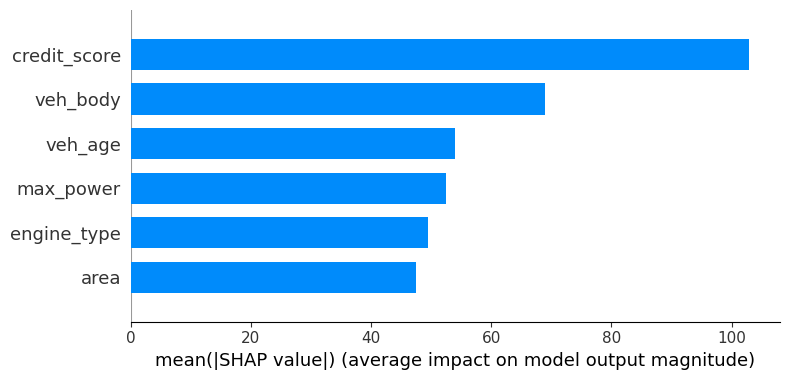

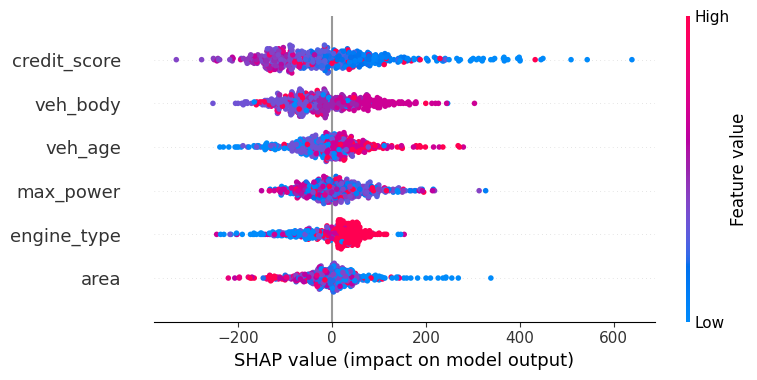

In [16]:
import shap

# SHAP expects a small sample for speed
explainer = shap.TreeExplainer(final_rf)

# Use a subset of validation set to compute SHAP values
X_sample = X_val.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

# Global Variable Importance
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# SHAP Summary Plot (beeswarm)
shap.summary_plot(shap_values, X_sample)


In [17]:
shap.initjs()

In [18]:
i = 10  # you can choose any index
shap.force_plot(explainer.expected_value, shap_values[i], X_sample.iloc[i,:])


11. Predict on Inference Dataset

Apply preprocessing

Predict

Save output CSV

In [19]:
# 11. Predict on Inference Dataset

# Prepare test data for prediction

test_clean = test.copy()

# Drop only fold/sample (id is needed later)
test_clean = test_clean.drop(columns=["fold", "sample"], errors='ignore')

# Apply label encoders to categorical columns
for col in cat_cols:
    test_clean[col] = encoders[col].transform(test_clean[col])

# Ensure missing columns (such as clm, numclaims) exist in test data
for col in X_train.columns:
    if col not in test_clean.columns:
        test_clean[col] = 0   # default value for missing feature

# Reorder columns to match training
X_test = test_clean[X_train.columns]

# Predict using final model
test_pred = final_rf.predict(X_test)

# Create output DataFrame
output = test.copy()
output["predicted_claimcst0"] = test_pred

# Save result
output.to_csv("../output/rf_predictions_inference.csv", index=False)

output.head()


,id,veh_value,exposure,veh_body,veh_age,gender,area,agecat,engine_type,max_power,driving_history_score,veh_color,marital_status,e_bill,time_of_week_driven,time_driven,trm_len,credit_score,low_education_ind,predicted_claimcst0
0,8295,6.36,0.777085,SUV,3,M,A,2,hybrid,128,81,silver,S,1,weekend,6am - 12pm,12,644.721808,0,825.701236
1,17625,2.56,0.528369,STNWG,1,F,A,1,dissel,178,94,white,S,1,weekday,12pm - 6pm,12,634.306196,0,476.029005
2,3802,6.18,0.384591,HDTOP,4,F,D,3,petrol,270,77,yellow,M,1,weekday,6pm - 12am,12,649.245139,0,288.690574
3,12865,6.49,0.116378,SUV,3,M,D,4,petrol,120,59,gray,S,1,weekday,6am - 12pm,12,647.594655,0,645.732572
4,6495,6.46,0.688417,SEDAN,2,F,C,4,petrol,94,81,green,S,1,weekday,6am - 12pm,12,657.550500,0,251.824127


12. Summary & Conclusions